# Machine Learning Classification of PAM50 in Two Multi-Omics Breast Cancer Studies

## Introduction

Breast cancer is a highly heterogeneous disease, with tumors exhibiting distinct molecular, histological, and clinical characteristics. Understanding this heterogeneity is critical for guiding treatment decisions and predicting patient outcomes. The Prediction Analysis of Microarray, 50 genes (PAM50) gene signature is a widely used molecular classifier that categorizes breast tumors into five intrinsic subtypes: Luminal A, Luminal B, HER2-enriched, Basal-like, and Normal-like. These subtypes are derived from the expression patterns of 50 key genes, which capture differences in hormone receptor signaling, proliferation, and growth factor pathways. Clinically, PAM50 subtyping is performed in specialized cancer centers and pathology laboratories using patient tumor samples. Gene expression is measured (commonly via RNA sequencing or targeted assays), normalized, and compared to subtype-specific reference profiles, allowing each tumor to be assigned to the subtype whose expression pattern it most closely resembles. This molecular classification provides valuable prognostic information and can inform treatment strategies, including hormone therapy, chemotherapy, and targeted HER2-directed therapy, making it a cornerstone of precision oncology for breast cancer patients.

**PAM50 Genes**
| **Function**            | **Genes**                                                                                                   |
| ------------------------------- | ----------------------------------------------------------------------------------------------------------- |
| Luminal / Hormone Signaling | ESR1, PGR, BCL2, SCUBE2, FOXA1, NAT1, BAG1                                                                  |
| Proliferation / Cell Cycle  | MKI67, CCNB1, MYC, KIF2C, KIF11, UBE2C, ANLN, CDC20, CDC6, CDCA1, EXO1, ORC6L, MELK, ACTR3B, CENPF, TMEM45B |
| HER2 / Growth Factor        | ERBB2, GRB7, MMP11                                                                                          |
| Basal / Cytoskeleton / EMT  | FOXC1, KRT5, EGFR                                                                                           |

**PAM50 Subtypes**
| **Subtype** | **Characteristics**                             | **Typical Clinical Features / Notes**                                |
| ----------------- | ----------------------------------------------- | -------------------------------------------------------------------- |
| Luminal A     | Hormone receptor–positive, low proliferation    | Best prognosis; responds well to hormone therapy                     |
| Luminal B     | Hormone receptor–positive, higher proliferation | Worse prognosis than Luminal A; may need chemo + hormone therapy     |
| HER2-enriched | High ERBB2/HER2 expression                      | Often hormone receptor–negative; responsive to HER2-targeted therapy |
| Basal-like    | Triple-negative, high proliferation             | Aggressive; limited targeted therapy options; often EMT-like         |
| Normal-like   | Expression resembles normal breast tissue       | Rare; clinical significance is less clear                            |


## Objective

This notebook presents an analysis of gene expression data using the PAM50 gene signature, a widely used classifier for breast cancer subtypes. The primary goal of this project is to process, explore, and model the data to accurately categorize samples into their respective subtypes and to extract meaningful biological insights from observed patterns. Additionally, the analysis will highlight the strengths of modern, multi-omics modalities, particularly those available in the TCGA dataset, and discuss how these datasets can provide a more comprehensive view of tumor biology.

## Datasets

Data from the METABRIC and TCGA studies were obtained from cBioPortal for Cancer Genomics (https://www.cbioportal.org/datasets) as separate csv files and were combined and preprocessed into the format imported below.

### METABRIC (Molecular Taxonomy of Breast Cancer International Consortium)

Curtis et al. performed one of the foundational molecular profiling studies of breast cancer, generating the METABRIC dataset, which includes genomic and transcriptomic data for ~2,000 primary breast tumors. This cohort is widely used as a benchmark for subtype analysis (including PAM50).

- Gene expression: microarray-based expression for ~25,000 genes

- Copy number alteration (CNA): discrete CNA events (e.g., ERBB2, MYC, CCND1, FGFR1, PTEN, RB1, TP53, PIK3CA)

- Clinical / phenotype data: age, tumor grade, stage, survival, PAM50 subtype

- Limited other -omics: no genome-wide mutation or methylation data publicly available

```
Curtis, C., Shah, S. P., Chin, S.-F., Turashvili, G., Rueda, O. M., Dunning, M. J., … Aparicio, S.; METABRIC Group (2012). The genomic and transcriptomic architecture of 2,000 breast tumours reveals novel subgroups. Nature, 486(7403), 346–352. https://doi.org/10.1038/nature10983
```

### TCGA (The Cancer Genome Atlas — Breast Invasive Carcinoma)

The TCGA Research Network’s comprehensive analysis represents a landmark effort in characterizing breast tumors across multiple molecular platforms, including gene expression data used for intrinsic subtype analyses like PAM50.

- Gene expression: RNA-seq normalized counts for ~20,000 genes

- Copy number variation (CNV): segment mean or GISTIC scores genome-wide

- Somatic mutation: mutation calls per gene (binary or variant counts)

- DNA methylation: beta values (Illumina 450k/850k)

- Clinical / phenotype data: age, stage, grade, survival, PAM50 subtype, treatment info

- Other multi-omics: miRNA-seq, protein expression (RPPA), and other tumor-specific features

```
The Cancer Genome Atlas Network (2012). Comprehensive molecular portraits of human breast tumours. Nature, 490(7418), 61–70. https://doi.org/10.1038/nature11412
```

## Import Libraries and Data

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from collections import Counter

from lazypredict.Supervised import LazyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

import optuna

### Import Data

Prior to importing, master csv files for each study were prepared by:

1. Gathering component multi-omics csv files and creating dataframes
2. Transposing `Sample_ID` and gene names as necessary
3. Resetting indices back to `Sample_ID` as appropriate
4. Appending `_expr` to gene names for gene expression data, `_cnv` for copy number variation, and so forth
5. Merging all component dataframes on `Sample_ID`
6. Ensuring the final dataframe has both integer `PAM50` and named `PAM50_Label` columns
7. Remove 'NC' rows from METABRIC data

In [2]:
# Import preprocessed csv files
tcga = pd.read_csv("tcga_data.csv")

metabric = pd.read_csv("metabric_data.csv")

## Exploratory Data Analysis

### PAM50 Subtype Distributions

Class counts:
 PAM50_Label
Basal      31
Her2      132
LumA      353
LumB       42
Normal    113
Name: count, dtype: int64


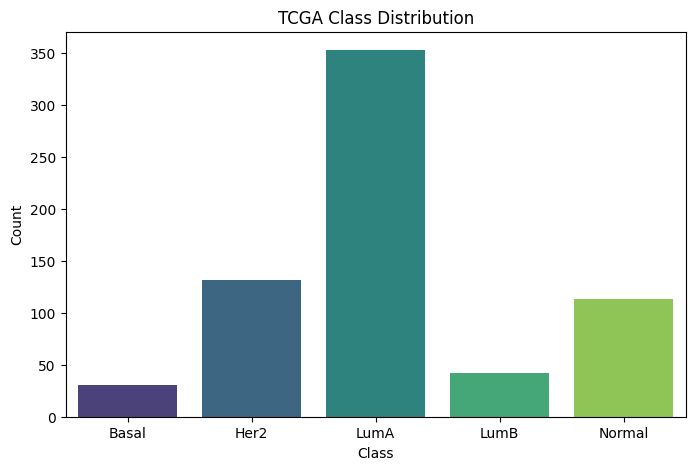

Class counts:
 PAM50_Label
Basal          209
Her2           224
LumA           700
LumB           475
Normal         148
claudin-low    218
Name: count, dtype: int64


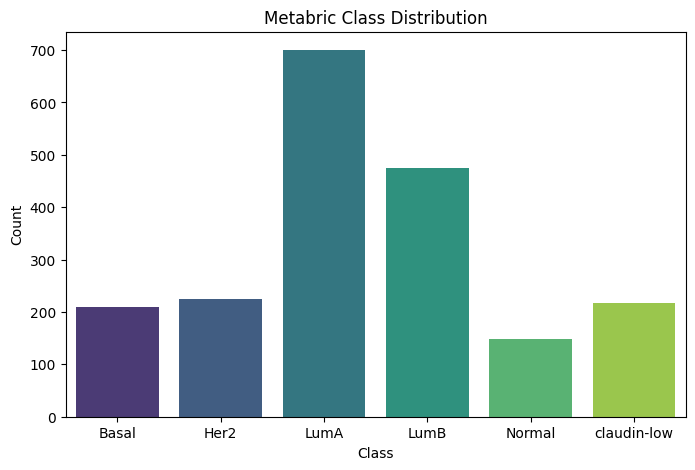

In [ ]:
# Plot class distributions
def plot_class_distribution(y, title="Class Distribution"):
    """
    Plots a bar chart of class counts.

    Parameters:
    - y: array-like (list, Series, or np.array) of target labels
    - title: string, plot title
    """
    # Make a Series if not already
    if not isinstance(y, pd.Series):
        y = pd.Series(y, name="Class")
    
    # Count each class
    counts = y.value_counts().sort_index()
    print("Class counts:\n", counts)
    
    # Plot
    plt.figure(figsize=(8,5))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()
    
# TCGA class distribution
plot_class_distribution(tcga['PAM50_Label'], title="TCGA PAM50 Subtype Distribution")

# Metabric class distribution
plot_class_distribution(metabric['PAM50_Label'], title="METABRIC PAM50 Subtype Distribution")

### Gene Expression per PAM50 Subtype

#### Violin Plots

Plotting the following genes: ['ESR1_expr', 'MKI67_expr', 'CCNB1_expr', 'CENPF_expr', 'EXO1_expr', 'CDC20_expr', 'TMEM45B_expr', 'MMP11_expr', 'GRB7_expr']


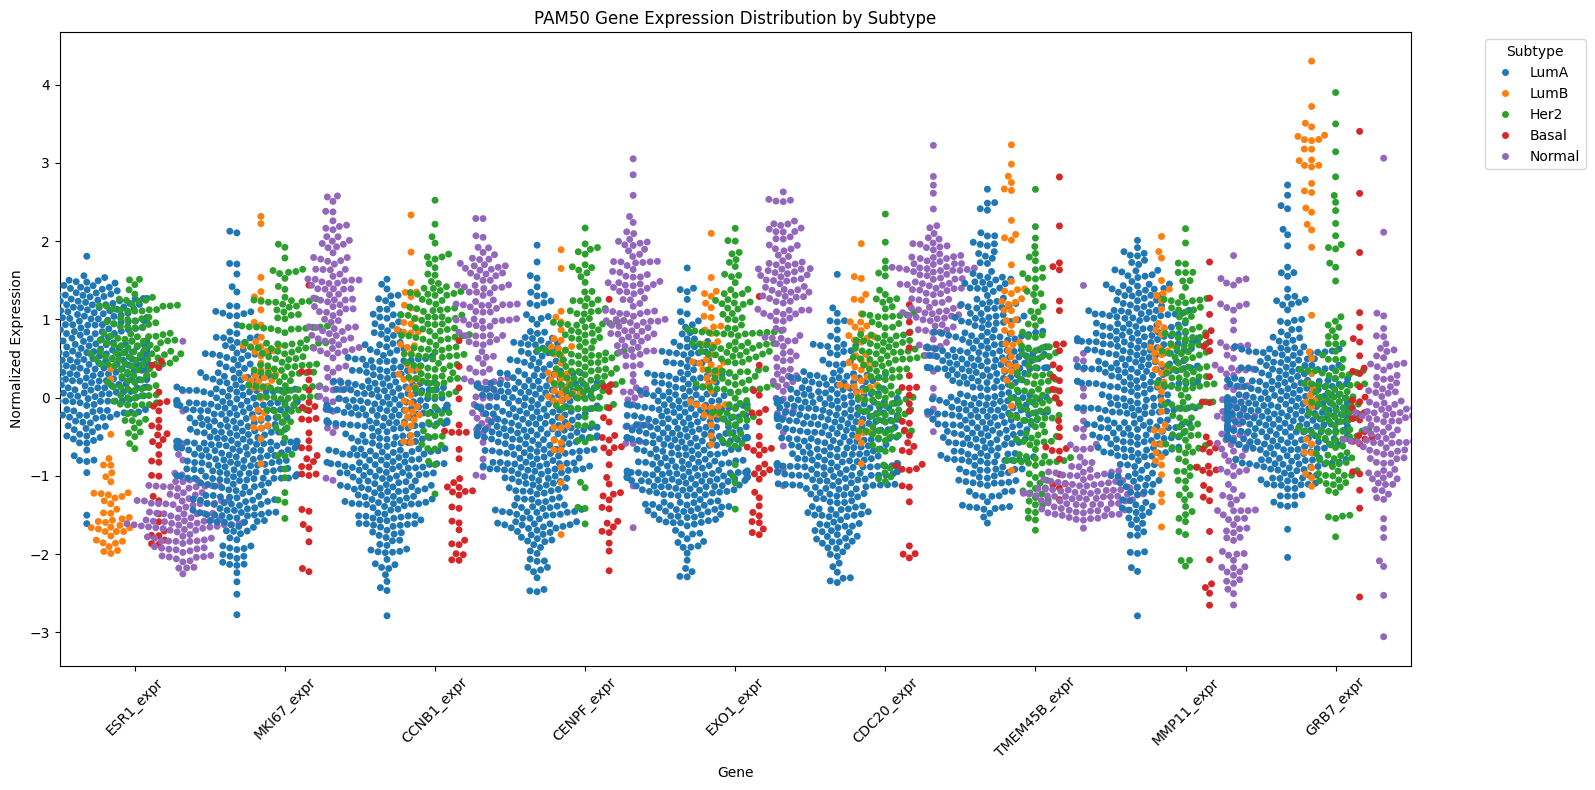

Plotting the following genes: ['ESR1_expr', 'PGR_expr', 'MKI67_expr', 'FOXC1_expr', 'KRT5_expr', 'BAG1_expr', 'CCNB1_expr', 'MELK_expr', 'ACTR3B_expr', 'CENPF_expr', 'EXO1_expr', 'NDC80_expr', 'UBE2C_expr', 'ANLN_expr', 'CDC20_expr', 'KIF2C_expr', 'TMEM45B_expr', 'MMP11_expr', 'GRB7_expr', 'EGFR_expr']


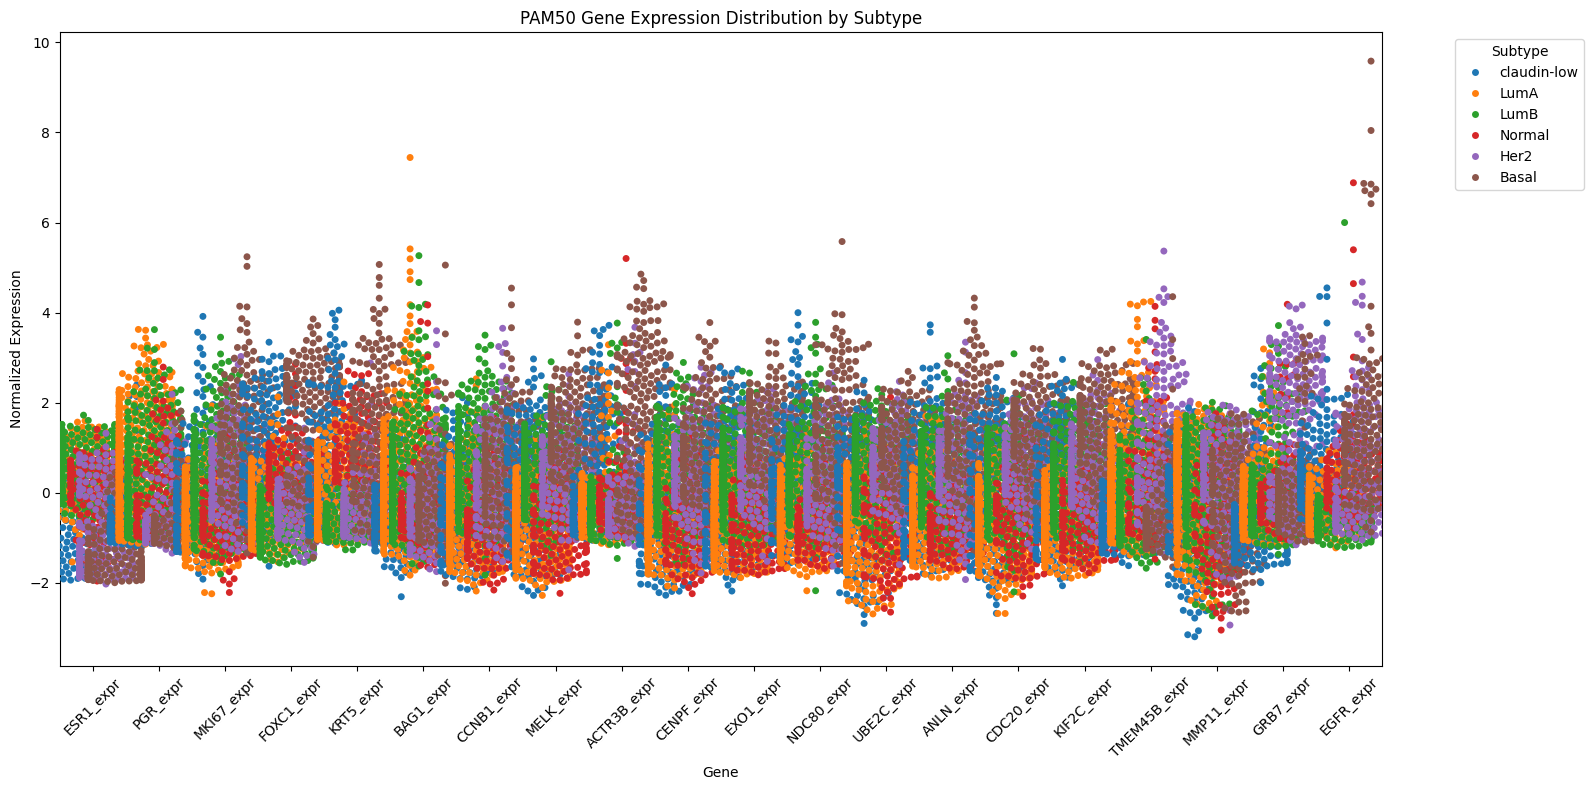

In [ ]:
# Violin plots for PAM50 genes
def plot_pam50_violin(df, pam50_genes=None, subtype_col='PAM50', figsize=(14,6), dataset_name='Study'):
    """
    Plots violin plots of PAM50 gene expression by subtype.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing expression data and subtype labels.
        Columns for expression should be <gene>_expr.
    pam50_genes : list, optional
        List of PAM50 gene names (without '_expr'). Defaults to common PAM50 genes.
    subtype_col : str
        Name of the column with PAM50 subtype labels. Default is 'PAM50'.
    figsize : tuple
        Figure size for the plot.

    Returns:
    --------
    None (displays a violin plot)
    """

    # Default PAM50 genes if not provided
    if pam50_genes is None:
        pam50_genes = ['ESR1','PGR','ERBB2','MKI67','FOXC1','KRT5','BAG1','CCNB1','MYC','MELK',
                       'ORC6L','ACTR3B','CENPF','EXO1','NDC80','UBE2C','ANLN','CDC20','CDC6','CDCA1',
                       'KIF2C','KIF11','TMEM45B','MMP11','GRB7','EGFR']

    # Append '_expr' to match DataFrame columns
    genes_of_interest = [gene + '_expr' for gene in pam50_genes]

    # Keep only columns that exist in df
    existing_genes = [gene for gene in genes_of_interest if gene in df.columns]

    if not existing_genes:
        raise ValueError("None of the PAM50 gene columns exist in the DataFrame!")

    print("Plotting the following genes:", existing_genes)

    # Melt for plotting
    melted_df = df.melt(id_vars=subtype_col, 
                        value_vars=existing_genes, 
                        var_name='Gene', 
                        value_name='Expression')
    
    # Remove _expr suffix for nicer labels
    melted_df['Gene'] = melted_df['Gene'].str.replace('_expr','')

    # Plot
    plt.figure(figsize=figsize)
    sns.violinplot(data=melted_df,
                   x='Gene',
                   y='Expression',
                   hue=subtype_col,
                   inner='quartile')
    plt.title('PAM50 Gene Expression Distribution by Subtype in {dataset_name}')
    plt.ylabel('Normalized Expression')
    plt.xlabel('Gene')
    plt.xticks(rotation=45)
    plt.legend(title='Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
# Plot PAM50 violin plots for TCGA
plot_pam50_violin(tcga, subtype_col='PAM50_Label', figsize=(16,8), dataset_name='TCGA')

# Plot PAM50 violin plots for METABRIC
plot_pam50_violin(metabric, subtype_col='PAM50_Label', figsize=(16,8), dataset_name='METABRIC')

#### Facet Grids

Plotting genes: ['ESR1_expr', 'MKI67_expr', 'CCNB1_expr', 'CENPF_expr', 'EXO1_expr', 'CDC20_expr', 'TMEM45B_expr', 'MMP11_expr', 'GRB7_expr']


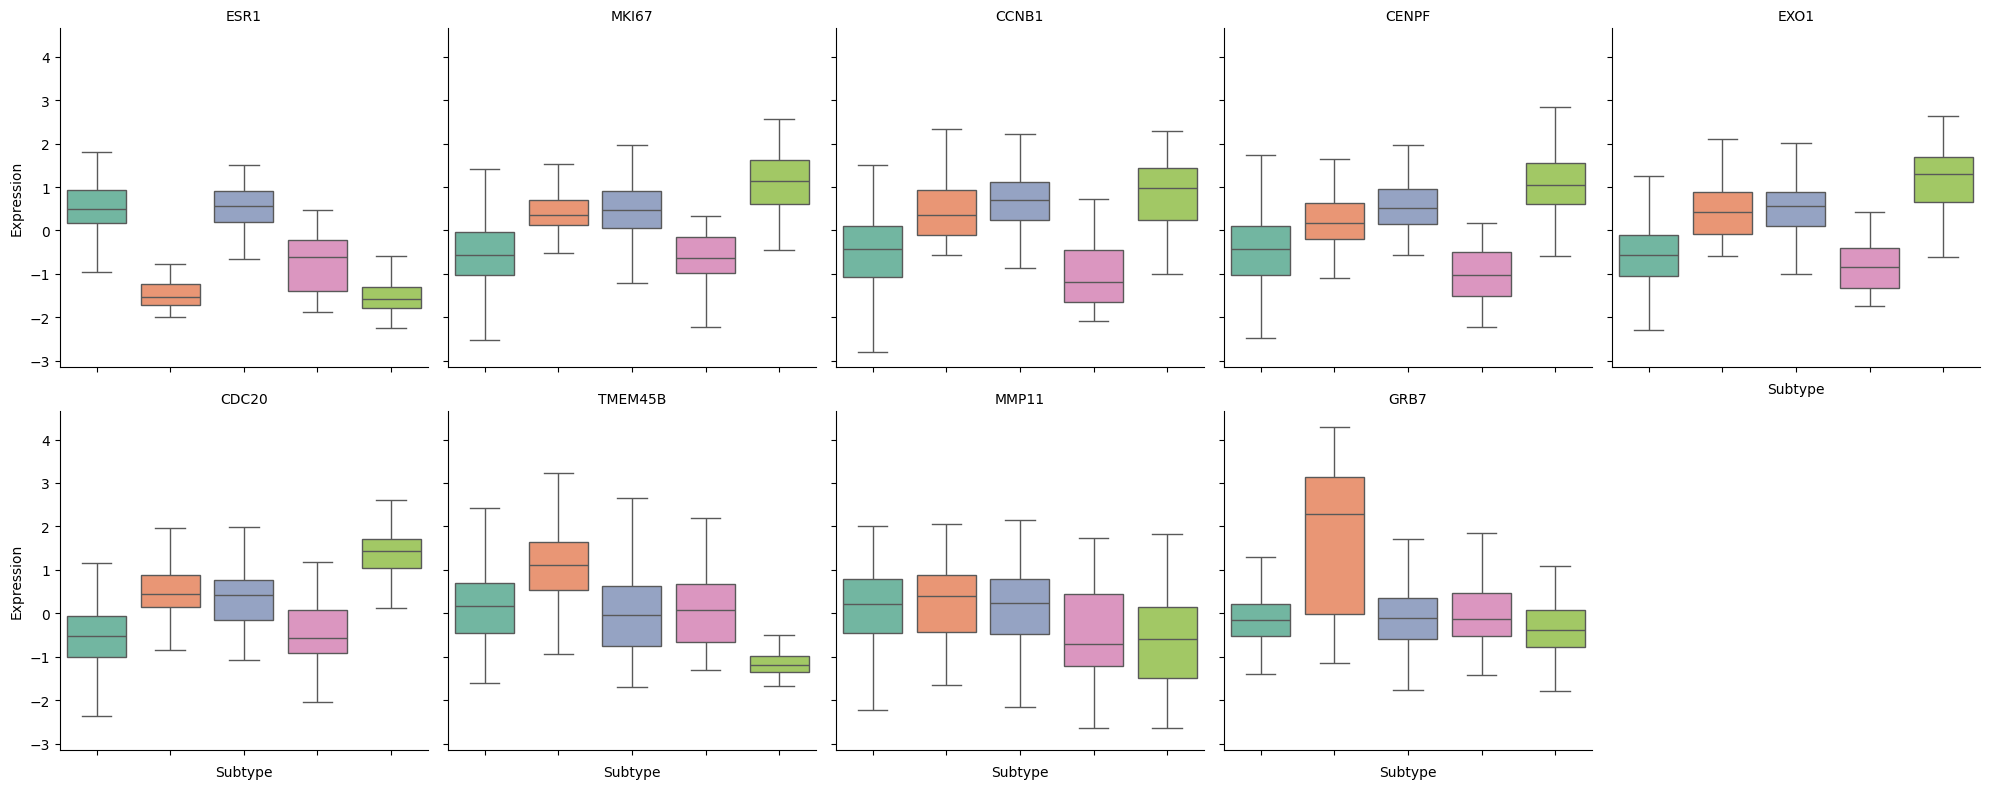

In [ ]:
# Facet grids for PAM50 genes
def plot_pam50_facetgrid(df, pam50_genes=None, subtype_col='PAM50', plot_type='box', col_wrap=5, figsize=(16,12), dataset_name='Study'):
    """
    Plots PAM50 gene expression using FacetGrid for clarity.

    Parameters:
    -----------
    df : pd.DataFrame
        Expression dataframe with columns <gene>_expr and PAM50 subtypes.
    pam50_genes : list, optional
        List of PAM50 gene names (without '_expr'). Defaults to common PAM50 genes.
    subtype_col : str
        Column name containing PAM50 subtypes.
    plot_type : str
        'box' or 'violin' for the type of plot inside each facet.
    col_wrap : int
        Number of columns in the FacetGrid.
    figsize : tuple
        Figure size for the entire FacetGrid.
    """

    # Default PAM50 genes if not provided
    if pam50_genes is None:
        pam50_genes = ['ESR1','PGR','ERBB2','MKI67','FOXC1','KRT5','BAG1','CCNB1','MYC','MELK',
                       'ORC6L','ACTR3B','CENPF','EXO1','NDC80','UBE2C','ANLN','CDC20','CDC6','CDCA1',
                       'KIF2C','KIF11','TMEM45B','MMP11','GRB7','EGFR']

    # Append '_expr'
    genes_of_interest = [gene + '_expr' for gene in pam50_genes]

    # Keep only existing columns
    existing_genes = [gene for gene in genes_of_interest if gene in df.columns]
    if not existing_genes:
        raise ValueError("No PAM50 genes found in DataFrame!")

    print("Plotting genes:", existing_genes)

    # Melt
    melted_df = df.melt(id_vars=subtype_col,
                        value_vars=existing_genes,
                        var_name='Gene',
                        value_name='Expression')

    # Remove _expr suffix for nicer labels
    melted_df['Gene'] = melted_df['Gene'].str.replace('_expr','')

    # Create FacetGrid
    g = sns.FacetGrid(melted_df, col="Gene", col_wrap=col_wrap, sharey=True, height=4, aspect=1)
    
    if plot_type == 'box':
        g.map_dataframe(sns.boxplot, x=subtype_col, y='Expression', palette='Set2', showfliers=False)
    elif plot_type == 'violin':
        g.map_dataframe(sns.violinplot, x=subtype_col, y='Expression', palette='Set2', inner='quartile')
    else:
        raise ValueError("plot_type must be 'box' or 'violin'")

    # Rotate x-axis labels
    for ax in g.axes.flatten():
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    g.set_titles("{col_name}")
    g.set_axis_labels("Subtype", "Expression")
    plt.tight_layout()
    plt.show()
    
# Plot PAM50 boxplots for TCGA
plot_pam50_facetgrid(tcga, subtype_col='PAM50_Label', plot_type='box', figsize=(16,12), dataset_name='TCGA')

# Plot PAM50 boxplots for Metabric
plot_pam50_facetgrid(metabric, subtype_col='PAM50_Label', plot_type='box', figsize=(16,12), dataset_name='METABRIC')

#### Heatmaps

In [ ]:
# Heatmaps for PAM50 genes
def plot_pam50_heatmap(df, pam50_genes=None, subtype_col='PAM50', figsize=(10,8), cmap='RdBu_r', dataset_name='Study'):
    """
    Plots a heatmap of median PAM50 gene expression by subtype.

    Parameters:
    -----------
    df : pd.DataFrame
        Expression dataframe with columns <gene>_expr and PAM50 subtypes.
    pam50_genes : list, optional
        List of PAM50 gene names (without '_expr'). Defaults to common PAM50 genes.
    subtype_col : str
        Column name containing PAM50 subtypes.
    figsize : tuple
        Figure size for the heatmap.
    cmap : str
        Colormap for heatmap.

    Returns:
    --------
    None (displays a heatmap)
    """

    # Default PAM50 genes
    if pam50_genes is None:
        pam50_genes = ['ESR1','PGR','ERBB2','MKI67','FOXC1','KRT5','BAG1','CCNB1','MYC','MELK',
                       'ORC6L','ACTR3B','CENPF','EXO1','NDC80','UBE2C','ANLN','CDC20','CDC6','CDCA1',
                       'KIF2C','KIF11','TMEM45B','MMP11','GRB7','EGFR']

    # Append '_expr'
    genes_of_interest = [gene + '_expr' for gene in pam50_genes]

    # Keep only genes present in df
    existing_genes = [gene for gene in genes_of_interest if gene in df.columns]
    if not existing_genes:
        raise ValueError("No PAM50 genes found in DataFrame!")

    print("Plotting genes:", existing_genes)

    # Compute median expression per gene per subtype
    median_expr = df.groupby(subtype_col)[existing_genes].median()

    # Optional: clean column names
    median_expr.columns = [col.replace('_expr','') for col in median_expr.columns]

    # Plot heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(median_expr.T, cmap=cmap, center=0, annot=True, fmt=".2f")
    plt.title(f'Median PAM50 Gene Expression per PAM50 Subtype in {dataset_name}')
    plt.ylabel('Gene')
    plt.xlabel('Subtype')
    plt.tight_layout()
    plt.show()
    
# Plot PAM50 heatmap for TCGA
plot_pam50_heatmap(tcga, subtype_col='PAM50_Label', figsize=(10,8), dataset_name='TCGA')

# Plot PAM50 heatmap for Metabric
plot_pam50_heatmap(metabric, subtype_col='PAM50_Label', figsize=(10,8), dataset_name='METABRIC')

SyntaxError: non-default argument follows default argument (2939437508.py, line 2)

#### Faceted KDE

Plotting genes: ['ESR1_expr', 'MKI67_expr', 'CCNB1_expr', 'CENPF_expr', 'EXO1_expr', 'CDC20_expr', 'TMEM45B_expr', 'MMP11_expr', 'GRB7_expr']


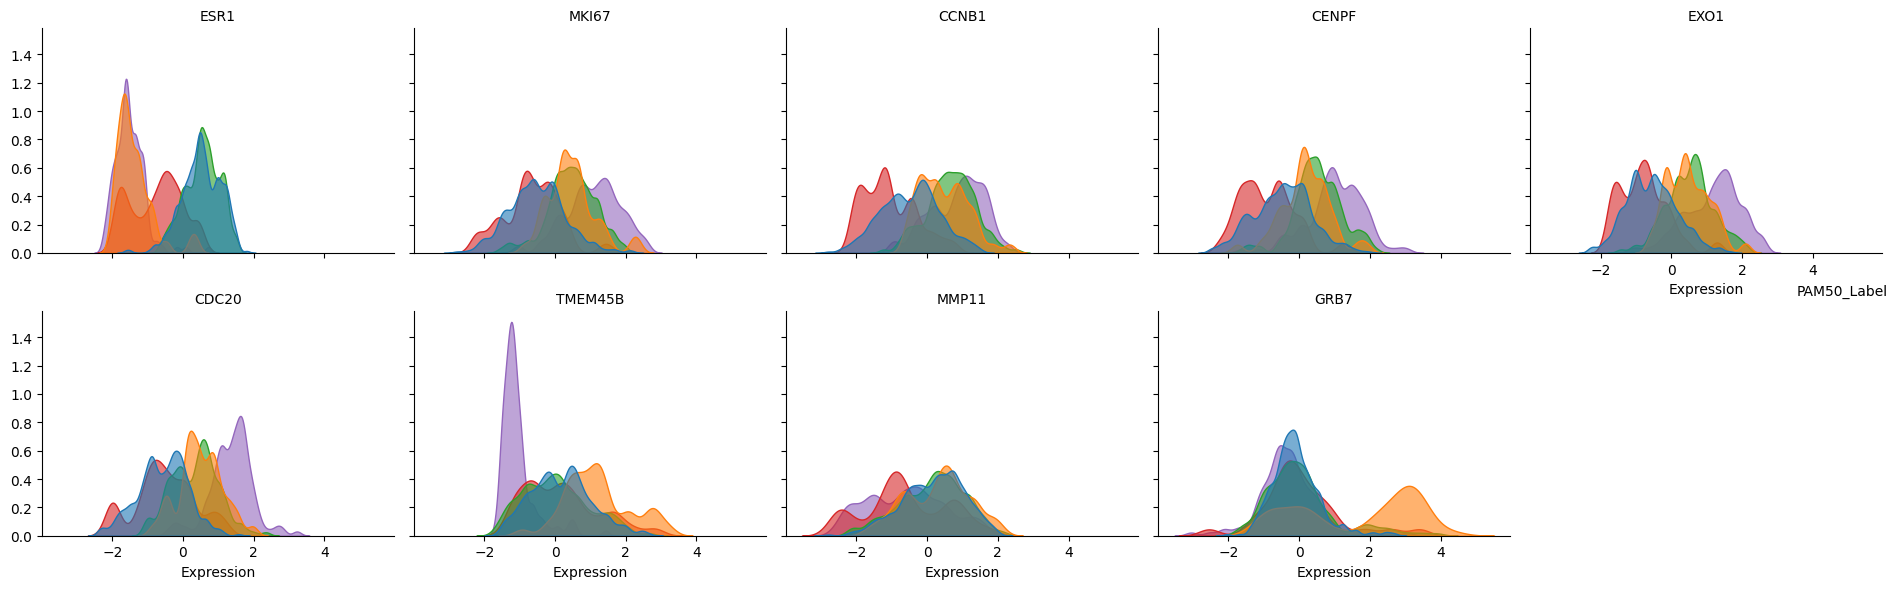

Plotting genes: ['ESR1_expr', 'PGR_expr', 'MKI67_expr', 'FOXC1_expr', 'KRT5_expr', 'BAG1_expr', 'CCNB1_expr', 'MELK_expr', 'ACTR3B_expr', 'CENPF_expr', 'EXO1_expr', 'NDC80_expr', 'UBE2C_expr', 'ANLN_expr', 'CDC20_expr', 'KIF2C_expr', 'TMEM45B_expr', 'MMP11_expr', 'GRB7_expr', 'EGFR_expr']


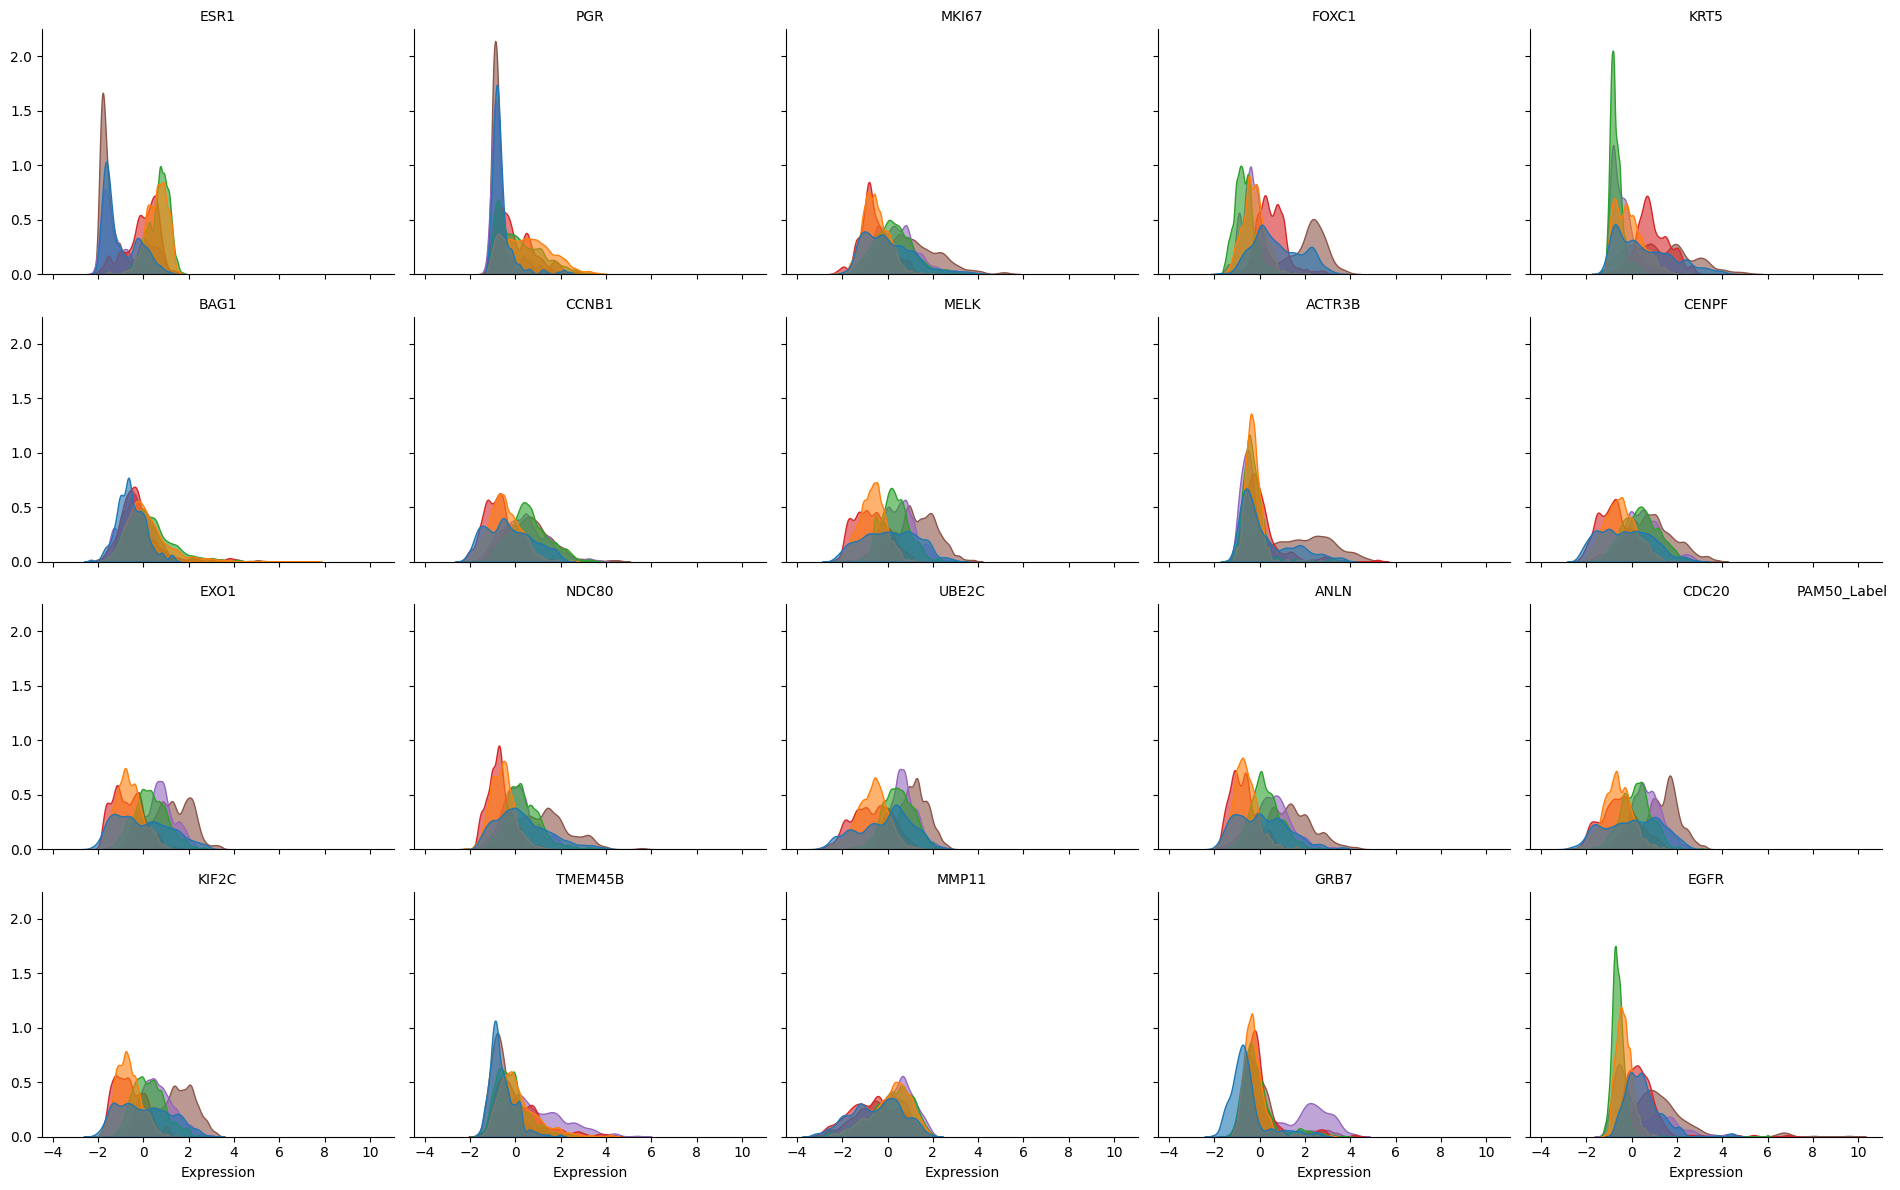

In [30]:
def plot_pam50_ridgeline_facet(df, pam50_genes=None, subtype_col='PAM50', col_wrap=5, figsize=(16,12), bw_adjust=0.5):
    """
    Creates a ridgeline-style plot for all PAM50 genes using FacetGrid with KDE plots.

    Parameters:
    -----------
    df : pd.DataFrame
        Expression dataframe with <gene>_expr columns and subtype column.
    pam50_genes : list, optional
        List of PAM50 gene names (without '_expr'). Defaults to common PAM50 genes.
    subtype_col : str
        Column name with PAM50 subtypes.
    col_wrap : int
        Number of columns in FacetGrid.
    figsize : tuple
        Figure size for the entire plot.
    bw_adjust : float
        Bandwidth adjustment for KDE plots (smaller = tighter curves).
    """

    # Default PAM50 genes
    if pam50_genes is None:
        pam50_genes = ['ESR1','PGR','ERBB2','MKI67','FOXC1','KRT5','BAG1','CCNB1','MYC','MELK',
                       'ORC6L','ACTR3B','CENPF','EXO1','NDC80','UBE2C','ANLN','CDC20','CDC6','CDCA1',
                       'KIF2C','KIF11','TMEM45B','MMP11','GRB7','EGFR']

    # Append '_expr' and filter to existing columns
    genes_of_interest = [gene + '_expr' for gene in pam50_genes if gene + '_expr' in df.columns]

    if not genes_of_interest:
        raise ValueError("No PAM50 gene expression columns found in DataFrame!")

    print("Plotting genes:", genes_of_interest)

    # Melt for FacetGrid
    melted_df = df.melt(id_vars=subtype_col,
                        value_vars=genes_of_interest,
                        var_name='Gene',
                        value_name='Expression')
    
    # Clean gene names
    melted_df['Gene'] = melted_df['Gene'].str.replace('_expr','')

    # Create FacetGrid
    g = sns.FacetGrid(melted_df, col="Gene", col_wrap=col_wrap, sharey=True, height=3, aspect=1.2)
    g.map_dataframe(sns.kdeplot, x="Expression", hue=subtype_col, fill=True, common_norm=False, alpha=0.6, bw_adjust=bw_adjust)
    
    # Adjust x-labels and titles
    for ax in g.axes.flatten():
        ax.set_xlabel('Expression')
        ax.set_ylabel('')
    g.set_titles("{col_name}")
    g.add_legend(title=subtype_col)
    plt.tight_layout()
    plt.show()

# Plot ridgeline plots for TCGA
plot_pam50_ridgeline_facet(tcga, subtype_col='PAM50_Label', figsize=(12,10))

# Plot ridgeline plots for METABRIC
plot_pam50_ridgeline_facet(metabric, subtype_col='PAM50_Label', figsize=(12,10))

### Copy Number Variation per PAM50 Subtype

#### Heatmap

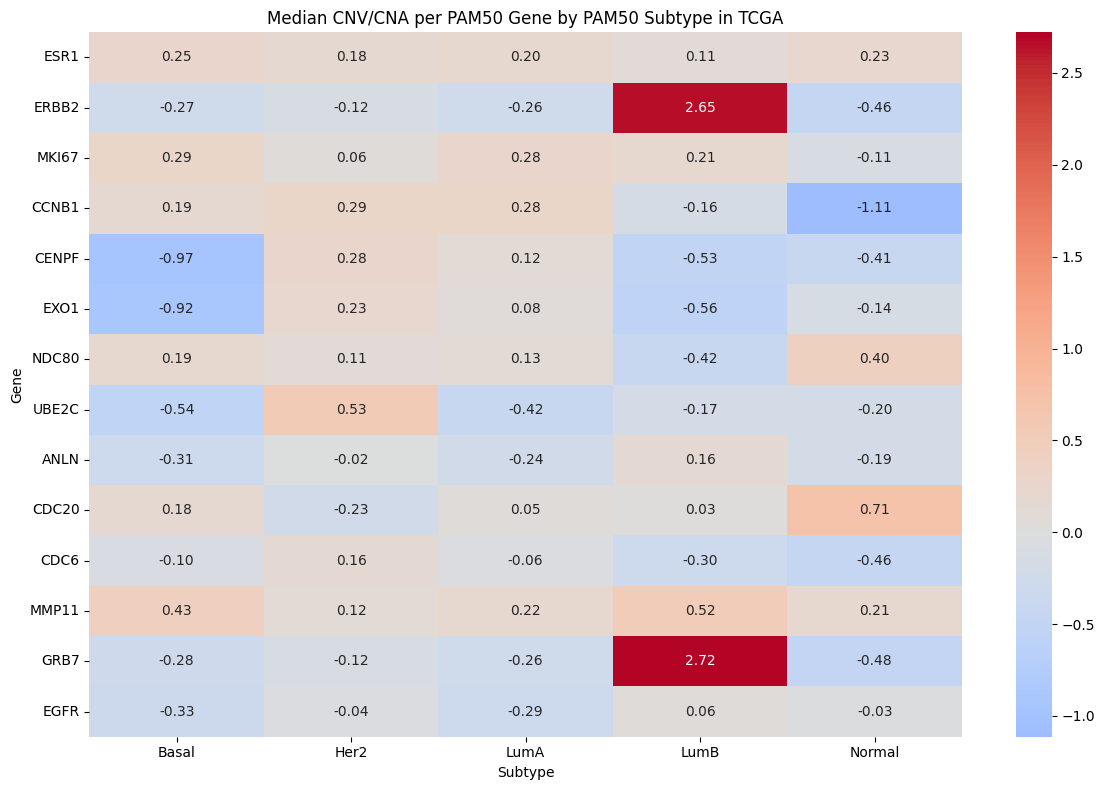

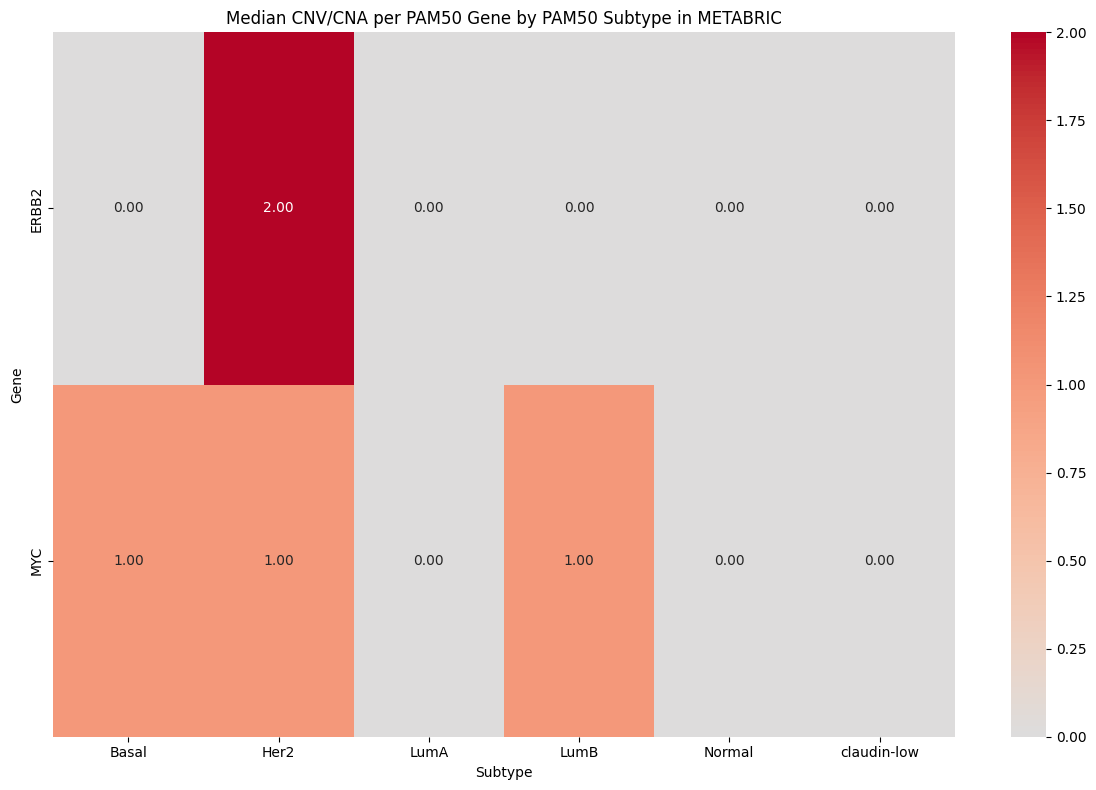

In [34]:
def plot_cnv_heatmap(df, pam50_genes=None, subtype_col='PAM50', figsize=(12,8), cmap='coolwarm', dataset_name='Study'):
    if pam50_genes is None:
        pam50_genes = ['ESR1','PGR','ERBB2','MKI67','FOXC1','KRT5','BAG1','CCNB1','MYC','MELK',
                       'ORC6L','ACTR3B','CENPF','EXO1','NDC80','UBE2C','ANLN','CDC20','CDC6','CDCA1',
                       'KIF2C','KIF11','TMEM45B','MMP11','GRB7','EGFR']
    
    # Choose columns that exist
    cnv_columns = []
    for g in pam50_genes:
        if g + '_cnv' in df.columns:
            cnv_columns.append(g + '_cnv')
        elif g + '_cna' in df.columns:
            cnv_columns.append(g + '_cna')

    if not cnv_columns:
        raise ValueError("No CNV or CNA columns found!")

    # Median per gene per subtype
    median_cnv = df.groupby(subtype_col)[cnv_columns].median()
    median_cnv.columns = [c.replace('_cnv','').replace('_cna','') for c in median_cnv.columns]

    # Heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(median_cnv.T, cmap=cmap, center=0, annot=True, fmt=".2f")
    plt.title(f'Median CNV/CNA per PAM50 Gene by PAM50 Subtype in {dataset_name}')
    plt.xlabel('Subtype')
    plt.ylabel('Gene')
    plt.tight_layout()
    plt.show()
    
# Plot CNV heatmap for TCGA
plot_cnv_heatmap(tcga, subtype_col='PAM50_Label', figsize=(12,8), dataset_name='TCGA')

# Plot CNV heatmap for METABRIC
plot_cnv_heatmap(metabric, subtype_col='PAM50_Label', figsize=(12,8), dataset_name='METABRIC')

## Preparation for Modeling

### Specify Variables

In [5]:
# Specify X and y and drop y labels
X_tcga = tcga.drop(columns=['PAM50', 'PAM50_Label', 'Sample_ID'])
y_tcga = tcga['PAM50']

X_metabric = metabric.drop(columns=['PAM50', 'PAM50_Label', 'Sample_ID'])
y_metabric = metabric['PAM50']

### Train-Test-Validation Split

In [6]:
# Train-test split (80%-10%-10%)
# TCGA
X_tcga_train, X_tcga_temp, y_tcga_train, y_tcga_temp = train_test_split(
    X_tcga, 
    y_tcga, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_tcga)
X_tcga_val, X_tcga_test, y_tcga_val, y_tcga_test = train_test_split(
    X_tcga_temp, 
    y_tcga_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_tcga_temp)

# Metabric
X_metabric_train, X_metabric_temp, y_metabric_train, y_metabric_temp = train_test_split(
    X_metabric, 
    y_metabric, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_metabric)
X_metabric_val, X_metabric_test, y_metabric_val, y_metabric_test = train_test_split(
    X_metabric_temp, 
    y_metabric_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_metabric_temp)

# Verify split shapes and contents
print(X_tcga_train.shape, X_tcga_val.shape, X_tcga_test.shape, 
      y_tcga_train.shape, y_tcga_val.shape, y_tcga_test.shape)

print(X_metabric_train.shape, X_metabric_val.shape, X_metabric_test.shape,
      y_metabric_train.shape, y_metabric_val.shape, y_metabric_test.shape)

# Convert all dtypes to float
X_tcga_train = X_tcga_train.astype(float)
X_tcga_val = X_tcga_val.astype(float)
X_tcga_test = X_tcga_test.astype(float)

X_metabric_train = X_metabric_train.astype(float)
X_metabric_val = X_metabric_val.astype(float)
X_metabric_test = X_metabric_test.astype(float)

# Make sure target is only integer value
y_tcga_train = y_tcga_train.astype(int)
y_tcga_val = y_tcga_val.astype(int)
y_tcga_test = y_tcga_test.astype(int)

# Verify dtypes
print(X_tcga_train.dtypes.value_counts())
print(X_metabric_train.dtypes.value_counts())

(536, 358) (67, 358) (68, 358) (536,) (67,) (68,)
(1579, 65) (197, 65) (198, 65) (1579,) (197,) (198,)
float64    358
Name: count, dtype: int64
float64    65
Name: count, dtype: int64


### Synthetic Minority Over-sampling Technique (SMOTE)

In [ ]:
# Apply SMOTE with counters to check class distribution before and after
smote = SMOTE(random_state=42)

print('Before SMOTE:', Counter(y_tcga_train))

X_tcga_train, y_tcga_train = smote.fit_resample(X_tcga_train, y_tcga_train)
X_metabric_train, y_metabric_train = smote.fit_resample(X_metabric_train, y_metabric_train)

print('After SMOTE:', Counter(y_tcga_train))

Before SMOTE: Counter({0: 282, 2: 105, 4: 90, 1: 34, 3: 25})
After SMOTE: Counter({0: 282, 2: 105, 4: 90, 1: 34, 3: 25})


## Modeling

### LazyClassifier

In [8]:
def lazyclassify(X_train, X_test, y_train, y_test):
    clf = LazyClassifier(predictions=True)
    models, predictions = clf.fit(X_train, X_test, y_train, y_test)
    return models.sort_values(by='Accuracy', ascending=False)

# Run LazyClassifier on TCGA data
lazyclassify(X_tcga_train, X_tcga_test, y_tcga_train, y_tcga_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004564 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 64081
[LightGBM] [Info] Number of data points in the train set: 536, number of used features: 358
[LightGBM] [Info] Start training from score -0.642227
[LightGBM] [Info] Start training from score -2.757774
[LightGBM] [Info] Start training from score -1.630174
[LightGBM] [Info] Start training from score -3.065258
[LightGBM] [Info] Start training from score -1.784324
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.88,0.81,None,0.88,0.60
ExtraTreesClassifier,0.88,0.75,None,0.87,0.21
LGBMClassifier,0.87,0.80,None,0.87,2.08
XGBClassifier,0.87,0.85,None,0.86,1.87
SVC,0.87,0.74,None,0.86,0.05
AdaBoostClassifier,0.84,0.86,None,0.84,1.33
BaggingClassifier,0.84,0.77,None,0.83,1.03
LogisticRegression,0.84,0.82,None,0.83,0.07
PassiveAggressiveClassifier,0.82,0.76,None,0.81,0.07


In [9]:
# Run LazyClassifier on Metabric data
lazyclassify(X_metabric_train, X_metabric_test, y_metabric_train, y_metabric_test)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12058
[LightGBM] [Info] Number of data points in the train set: 1579, number of used features: 65
[LightGBM] [Info] Start training from score -1.036610
[LightGBM] [Info] Start training from score -1.424376
[LightGBM] [Info] Start training from score -2.177161
[LightGBM] [Info] Start training from score -2.246553
[LightGBM] [Info] Start training from score -2.585424
[LightGBM] [Info] Start training from score -2.205492
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.80,0.77,None,0.80,1.10
LGBMClassifier,0.80,0.75,None,0.80,0.86
RandomForestClassifier,0.80,0.72,None,0.79,0.80
ExtraTreesClassifier,0.80,0.70,None,0.78,0.36
SVC,0.78,0.71,None,0.77,0.10
LogisticRegression,0.77,0.72,None,0.77,0.07
LinearSVC,0.76,0.68,None,0.75,0.07
LinearDiscriminantAnalysis,0.76,0.69,None,0.75,0.03
RidgeClassifierCV,0.76,0.66,None,0.74,0.03


### RandomForestClassifier (Baseline)

In [ ]:
# Baseline Random Forest Classifier
def random_forest_classifier(X_train, y_train, X_test, y_test):
    rf = RandomForestClassifier(n_estimators=300,
                                max_depth=10, 
                                class_weight='balanced',
                                random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Accuracy - use all 3
    accuracy = accuracy_score(y_test, y_pred)
    print("Accuracy:", accuracy)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # 5-fold CV on the training set
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    print("CV Accuracy Scores:", scores)
    print("Mean CV Accuracy:", scores.mean())

# TCGA Random Forest
random_forest_classifier(X_tcga_train, y_tcga_train, X_tcga_test, y_tcga_test)

Accuracy: 0.8823529411764706

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92        36
           1       1.00      0.75      0.86         4
           2       0.89      0.57      0.70        14
           3       1.00      0.67      0.80         3
           4       0.92      1.00      0.96        11

    accuracy                           0.88        68
   macro avg       0.93      0.80      0.85        68
weighted avg       0.89      0.88      0.87        68

CV Accuracy Scores: [0.88888889 0.82242991 0.8411215  0.79439252 0.85981308]
Mean CV Accuracy: 0.8413291796469367


In [11]:
# Metabric Random Forest
random_forest_classifier(X_metabric_train, y_metabric_train, X_metabric_test, y_metabric_test)

Accuracy: 0.803030303030303

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.87      0.87        70
         1.0       0.79      0.96      0.87        48
         2.0       0.89      0.70      0.78        23
         3.0       0.63      0.81      0.71        21
         4.0       0.78      0.50      0.61        14
         5.0       0.80      0.55      0.65        22

    accuracy                           0.80       198
   macro avg       0.79      0.73      0.75       198
weighted avg       0.81      0.80      0.80       198

CV Accuracy Scores: [0.78797468 0.74050633 0.78481013 0.80063291 0.79365079]
Mean CV Accuracy: 0.7815149688567409


### RandomForestClassifier (Optuna)

In [12]:
# Optuna Hyperparameter Optimization for Random Forest
def random_forest_classifier_optuna(X_train, y_train, X_test, y_test):
    def objective(trial):
        rf = RandomForestClassifier(
            n_estimators=trial.suggest_int('n_estimators', 100, 500),
            max_depth=trial.suggest_int('max_depth', 5, 20),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
            max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        
        cv_scores = cross_val_score(
            rf,
            X_train,
            y_train,
            cv=5,
            scoring='f1_macro'
        )
        
        return cv_scores.mean()

        
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)

    print("Best CV F1-macro:", study.best_value)
    print("Best hyperparameters:", study.best_params)

    # ---- Final model trained on full training set ----
    best_rf = RandomForestClassifier(
        **study.best_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    best_rf.fit(X_train, y_train)
    y_pred = best_rf.predict(X_test)

    print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
    print("Test F1-macro:", f1_score(y_test, y_pred, average='macro'))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return best_rf

# TCGA Random Forest with Optuna    
random_forest_classifier_optuna(X_tcga_train, y_tcga_train, X_tcga_test, y_tcga_test)

[I 2026-01-21 19:53:55,921] A new study created in memory with name: no-name-05d25447-787d-449a-9ffe-64f4e979b5d7
[I 2026-01-21 19:53:57,706] Trial 0 finished with value: 0.6553902835801514 and parameters: {'n_estimators': 250, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.6553902835801514.
[I 2026-01-21 19:53:59,857] Trial 1 finished with value: 0.7717923133428515 and parameters: {'n_estimators': 291, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.7717923133428515.
[I 2026-01-21 19:54:01,104] Trial 2 finished with value: 0.6077312629188736 and parameters: {'n_estimators': 164, 'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.7717923133428515.
[I 2026-01-21 19:54:02,535] Trial 3 finished with value: 0.7622601283057765 and parameters: {'n_estimators': 184, 'max_depth': 13, 'm

Best CV F1-macro: 0.7902102826706701
Best hyperparameters: {'n_estimators': 115, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt'}

Test Accuracy: 0.9117647058823529
Test F1-macro: 0.9022066034651847

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        36
           1       1.00      0.75      0.86         4
           2       0.90      0.64      0.75        14
           3       1.00      1.00      1.00         3
           4       0.92      1.00      0.96        11

    accuracy                           0.91        68
   macro avg       0.94      0.88      0.90        68
weighted avg       0.91      0.91      0.91        68



,n_estimators,115
,criterion,'gini'
,max_depth,19
,min_samples_split,4
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# Metabric Random Forest with Optuna
random_forest_classifier_optuna(X_metabric_train, y_metabric_train, X_metabric_test, y_metabric_test)

[I 2026-01-21 19:55:16,226] A new study created in memory with name: no-name-9a82c511-2d45-456b-8b62-5fdd51fa204c
[I 2026-01-21 19:55:18,059] Trial 0 finished with value: 0.7191268785560239 and parameters: {'n_estimators': 190, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7191268785560239.
[I 2026-01-21 19:55:19,152] Trial 1 finished with value: 0.7076985357737503 and parameters: {'n_estimators': 123, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.7191268785560239.
[I 2026-01-21 19:55:21,545] Trial 2 finished with value: 0.7211878819880648 and parameters: {'n_estimators': 268, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.7211878819880648.
[I 2026-01-21 19:55:23,159] Trial 3 finished with value: 0.7178352576531988 and parameters: {'n_estimators': 181, 'max_depth': 19, 'mi

Best CV F1-macro: 0.7290956725925726
Best hyperparameters: {'n_estimators': 299, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2'}

Test Accuracy: 0.8181818181818182
Test F1-macro: 0.7622022136777994

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91        70
         1.0       0.83      0.92      0.87        48
         2.0       0.84      0.70      0.76        23
         3.0       0.63      0.81      0.71        21
         4.0       0.75      0.64      0.69        14
         5.0       0.75      0.55      0.63        22

    accuracy                           0.82       198
   macro avg       0.78      0.75      0.76       198
weighted avg       0.82      0.82      0.81       198



,n_estimators,299
,criterion,'gini'
,max_depth,15
,min_samples_split,6
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### XGBoost

### Neural Network